# So sánh hiệu suất hai mô hình InsightFace: buffalo_l vs uriel

Notebook này sử dụng thư viện insightface để so sánh hiệu suất của hai mô hình nhận diện khuôn mặt:
- **buffalo_l** (models/original/buffalo_l)
- **uriel** (models/merged/uriel)

So sánh được thực hiện trên các tập dữ liệu:
- **dataset/val** (mỗi subfolder là một nhãn)
- **dataset/test/** (mỗi subfolder là một tập test riêng)

Các bước thực hiện:
1. Cài đặt và import thư viện
2. Tải và khởi tạo hai mô hình
3. Định nghĩa hàm trích xuất embedding
4. Đánh giá hiệu suất trên val
5. Đánh giá hiệu suất trên từng tập test
6. So sánh và trực quan hóa kết quả

## 1. Cài đặt và import các thư viện cần thiết

- Cài đặt insightface nếu chưa có
- Import các thư viện: insightface, numpy, pandas, matplotlib, os, tqdm

In [1]:
# Cài đặt insightface nếu chưa có
try:
    import insightface
except ImportError:
    !pip install insightface
    import insightface

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from glob import glob

/opt/miniconda3/envs/face_recognition/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Tải và khởi tạo hai mô hình insightface

- Tải hai mô hình từ models/original/buffalo_l và models/merged/uriel
- Khởi tạo các đối tượng model để sử dụng cho việc trích xuất embedding

In [2]:
# Đường dẫn tới hai backbone
buffalo_l_path = 'models/original/buffalo_l/w600k_r50.onnx'
uriel_path = 'models/merged/uriel/w600k_r50.onnx'

from insightface.model_zoo import get_model

buffalo_l = get_model(buffalo_l_path)
buffalo_l.prepare(ctx_id=0)

uriel = get_model(uriel_path)
uriel.prepare(ctx_id=0)

models = {'buffalo_l': buffalo_l, 'uriel': uriel}

/opt/miniconda3/envs/face_recognition/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


## 3. Định nghĩa hàm trích xuất embedding

- Hàm nhận đầu vào là đường dẫn ảnh và model, trả về embedding vector
- Có thể sử dụng batch processing để tăng tốc

In [3]:
from PIL import Image

def extract_embedding(img_path, model):
    img = Image.open(img_path).convert('RGB')
    img = np.asarray(img)
    emb = model.get_feat(img)
    # Đảm bảo emb là vector 1D
    if emb.ndim == 3:
        emb = emb.mean(axis=(1, 2))
    elif emb.ndim == 2:
        emb = emb.flatten()
    return emb

def extract_embeddings_batch(img_paths, model):
    embs = []
    for img_path in tqdm(img_paths):
        embs.append(extract_embedding(img_path, model))
    return np.stack(embs)

## 4. Đánh giá hiệu suất trên tập val

- Duyệt qua các subfolder trong dataset/val (mỗi subfolder là một nhãn)
- Trích xuất embedding cho từng ảnh
- Tính toán ma trận khoảng cách/cosine similarity
- Đánh giá accuracy hoặc top-1 accuracy cho từng model

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

def evaluate_on_val(model, val_dir):
    labels = []
    img_paths = []
    for label in os.listdir(val_dir):
        label_path = os.path.join(val_dir, label)
        if os.path.isdir(label_path):
            for img_file in glob(os.path.join(label_path, '*')):
                img_paths.append(img_file)
                labels.append(label)
    embs = extract_embeddings_batch(img_paths, model)
    sims = cosine_similarity(embs, embs)
    preds = np.argmax(sims - np.eye(len(sims))*1e6, axis=1)
    pred_labels = [labels[i] for i in preds]
    acc = np.mean([l1 == l2 for l1, l2 in zip(labels, pred_labels)])
    return acc, labels, pred_labels, sims

val_dir = 'dataset/val'
val_results = {}
for model_name, model in models.items():
    acc, labels, pred_labels, sims = evaluate_on_val(model, val_dir)
    val_results[model_name] = {'accuracy': acc, 'labels': labels, 'pred_labels': pred_labels, 'sims': sims}
    print(f"{model_name} accuracy on val: {acc:.4f}")

100%|██████████| 448/448 [00:25<00:00, 17.56it/s]


buffalo_l accuracy on val: 1.0000


100%|██████████| 448/448 [00:27<00:00, 16.58it/s]

uriel accuracy on val: 1.0000


## 5. Đánh giá hiệu suất trên từng tập test

- Duyệt qua từng folder con trong dataset/test/
- Thực hiện tương tự như với tập val: trích xuất embedding, tính toán similarity, đánh giá accuracy cho từng model trên từng tập test

In [5]:
test_root = 'dataset/test'
test_results = {}
for test_set in os.listdir(test_root):
    test_dir = os.path.join(test_root, test_set)
    if not os.path.isdir(test_dir):
        continue
    test_results[test_set] = {}
    for model_name, model in models.items():
        acc, labels, pred_labels, sims = evaluate_on_val(model, test_dir)
        test_results[test_set][model_name] = {'accuracy': acc, 'labels': labels, 'pred_labels': pred_labels, 'sims': sims}
        print(f"{model_name} accuracy on {test_set}: {acc:.4f}")

100%|██████████| 1456/1456 [01:46<00:00, 13.66it/s]


buffalo_l accuracy on lfw_decrease: 0.9924


100%|██████████| 1456/1456 [01:46<00:00, 13.64it/s]


uriel accuracy on lfw_decrease: 0.9732


100%|██████████| 6024/6024 [07:17<00:00, 13.78it/s]


...

uriel accuracy on special_test: 0.7483


100%|██████████| 128/128 [00:11<00:00, 10.87it/s]


buffalo_l accuracy on remarkable-faces: 0.7500


100%|██████████| 128/128 [00:11<00:00, 11.03it/s]

uriel accuracy on remarkable-faces: 0.5625


## 6. So sánh và trực quan hóa kết quả

- Tổng hợp kết quả accuracy của hai mô hình trên val và từng test dataset
- Trực quan hóa bằng bảng và biểu đồ (matplotlib hoặc seaborn)

,dataset,buffalo_l,uriel
0,val,1.000000,1.000000
1,lfw_decrease,0.992445,0.973214
2,train,0.812251,0.919655
3,special_test,0.859799,0.748257
4,remarkable-faces,0.750000,0.562500


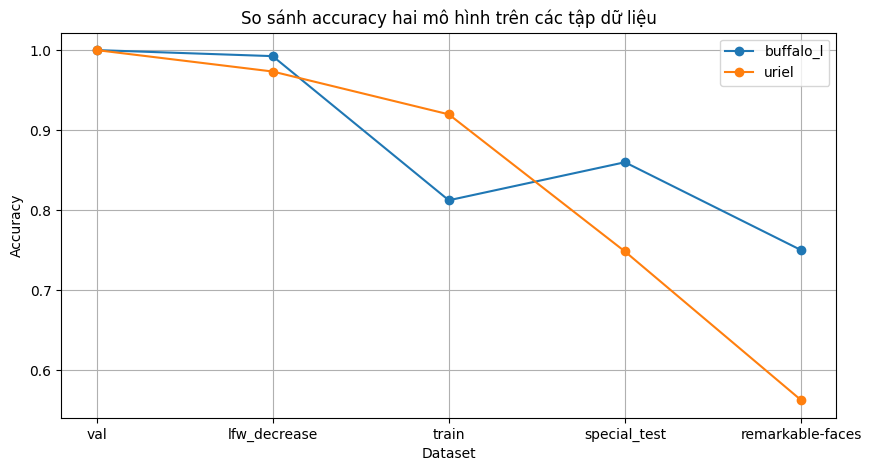

In [6]:
# Tổng hợp kết quả accuracy
summary = []
summary.append({'dataset': 'val', 'buffalo_l': val_results['buffalo_l']['accuracy'], 'uriel': val_results['uriel']['accuracy']})
for test_set in test_results:
    summary.append({
        'dataset': test_set,
        'buffalo_l': test_results[test_set]['buffalo_l']['accuracy'],
        'uriel': test_results[test_set]['uriel']['accuracy']
    })
df = pd.DataFrame(summary)
display(df)

# Vẽ biểu đồ so sánh
plt.figure(figsize=(10,5))
plt.plot(df['dataset'], df['buffalo_l'], marker='o', label='buffalo_l')
plt.plot(df['dataset'], df['uriel'], marker='o', label='uriel')
plt.ylabel('Accuracy')
plt.xlabel('Dataset')
plt.title('So sánh accuracy hai mô hình trên các tập dữ liệu')
plt.legend()
plt.grid(True)
plt.show()